# Decision trees - Binary Classification

Note

In this class we attempt to follow the same flow (whenever possible or applicable) to ensure proper pipelines
* 0. Setup
* 1. Data Loading and Exploration
* 2. Data Processing
* 3. Model Building
* 4. Evaluation

## 0. Setup

In this notebook, we'll explore Decision Trees for classification using the Palmer Penguins dataset.

In [371]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Data Loading and Exploration

Let's start by loading our dataset and exploring its characteristics.

### The Data

We are going to use the 'Palmer Penguins' dataset because penguins are funny creatures. More info can be found at https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

<img src="penguin.jpg" style="max-width:400px">


Summary:
The data folder contains two CSV files. For intro courses/examples, you probably want to use the first one (penguins_size.csv).

* penguins_size.csv: Simplified data from original penguin data sets. Contains variables:

    * species: penguin species (Chinstrap, Adélie, or Gentoo)
    * culmen_length_mm: culmen length (mm)
    * culmen_depth_mm: culmen depth (mm)
    * flipper_length_mm: flipper length (mm)
    * body_mass_g: body mass (g)
    * island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
    * sex: penguin sex

* (Not used) penguins_lter.csv: Original combined data for 3 penguin species  

Note: The culmen is "the upper ridge of a bird's beak" 

**Our goal is to create a model that can help predict a species of a penguin based on physical attributes, then we can use that model to help researchers classify penguins in the field, instead of needing an experienced biologist**

In [372]:
# load the data
df = pd.read_csv("datasets/penguins_size.csv")

In [373]:
# get the information (info) about the data
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [374]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [375]:
# drop na
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    str    
 1   island             334 non-null    str    
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.9 KB


Visualize the data using a pairplot

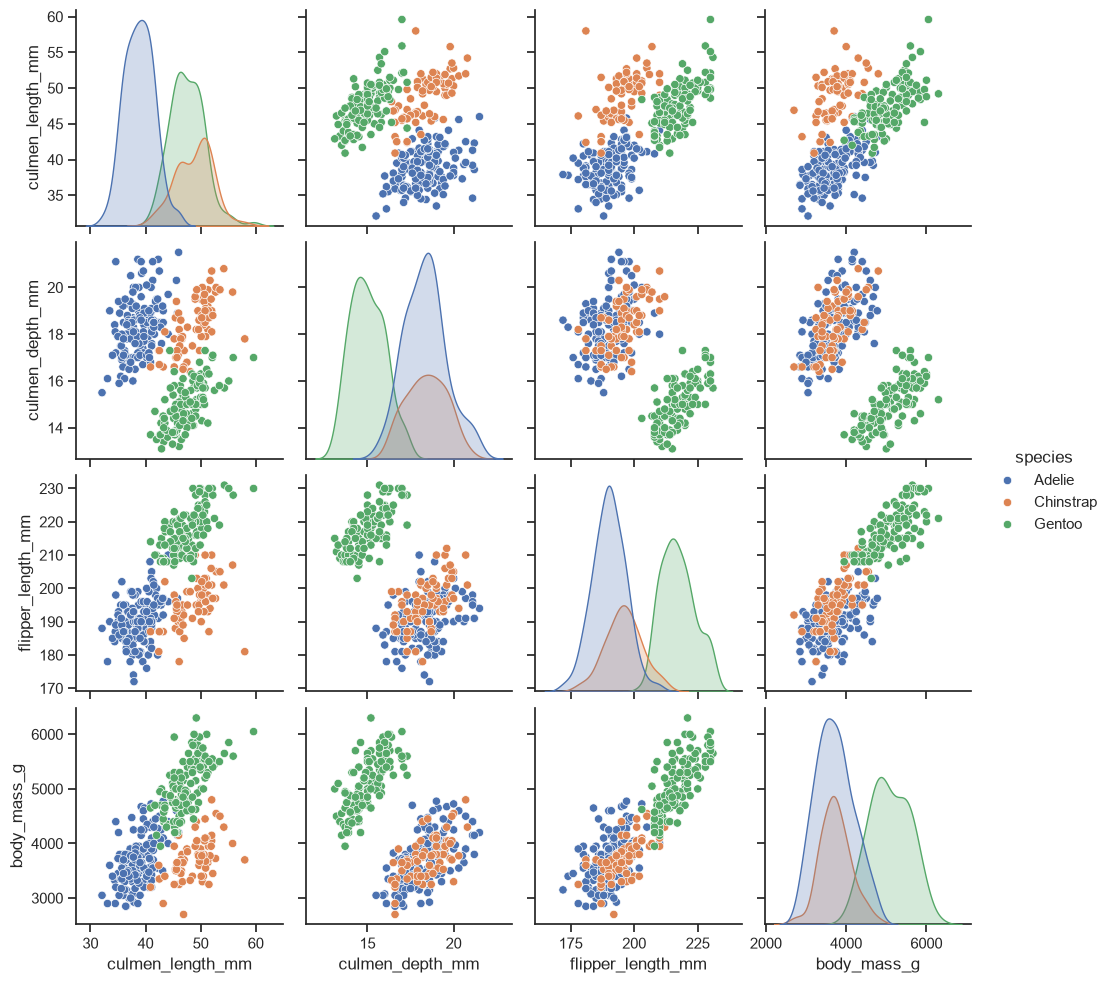

In [376]:
import seaborn as sns 
sns.set_theme(style="ticks")
sns.pairplot(df, hue="species")

In [377]:
# count values for each species
df['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

## 2. Data Processing

Now that we've explored our data, let's prepare it for model training.

In [378]:
# create dummy variables and define X and y
X = pd.get_dummies(df.drop('species',axis=1),drop_first=True)
y = df['species']

In [379]:
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True
...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,False


In [380]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

**Data cleaning notes**

1. After `dropna()` I have 334 of the 344 penguins. The model can't handle empty values, so those 10 rows go. Filling them in (imputing) would have kept them, but for 10 rows it isn't worth it here.
2. `island` becomes only 2 columns. Biscoe is the baseline: a 0 in both `island_Dream` and `island_Torgersen` means Biscoe, so a third column would repeat information.
3. One penguin has `sex = "."`. That's a typo, not an empty value, so `dropna()` keeps it. Because of it `sex` has three values (".", FEMALE, MALE), `drop_first` drops the "." column, and both `sex_FEMALE` and `sex_MALE` stay. One penguin won't change the model much, but I only noticed it by running `value_counts()`.


### Train | Test Split

In [381]:
from sklearn.model_selection import train_test_split

In [382]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

X_train.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
194,50.9,19.1,196.0,3550.0,True,False,False,True
22,35.9,19.2,189.0,3800.0,False,False,True,False
92,34.0,17.1,185.0,3400.0,True,False,True,False
149,37.8,18.1,193.0,3750.0,True,False,False,True
156,52.7,19.8,197.0,3725.0,True,False,False,True


## 3. Model Building

Let's build and train our Decision Tree model.

In [383]:
from sklearn.tree import DecisionTreeClassifier

In [384]:
Dtree = DecisionTreeClassifier()
Dtree.fit(X_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [385]:
preds = Dtree.predict(X_test)

## 4. Evaluation

In [386]:
from sklearn import tree

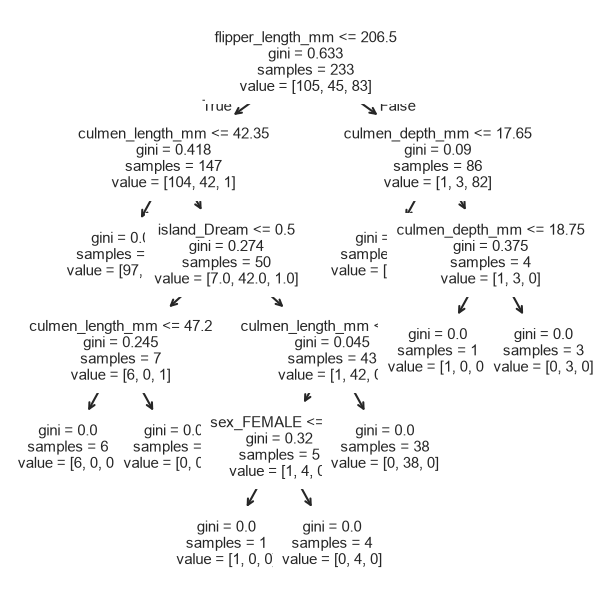

In [387]:
plt.figure(figsize = (5,5), dpi = 150)
tree.plot_tree(Dtree, fontsize = 7, 
               feature_names = ['culmen_length_mm', 'culmen_depth_mm', 
                                'flipper_length_mm','body_mass_g', 
                                'island_Dream', 'island_Torgersen', 
                                'sex_FEMALE','sex_MALE']);

In the root, the decision tree hasnt' started splitting so the data is still impure, later, it keeps splitting based on the features and since there is no gini impurity limit, it splits until it can classify one specie at the end, making the tree pure.

In [388]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

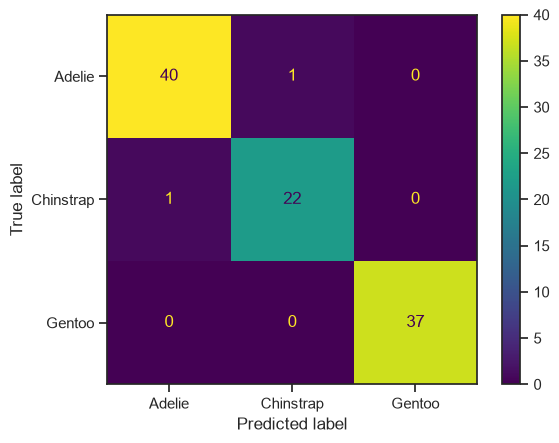

In [389]:
cm = confusion_matrix(y_test,preds)
CM_plot = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=Dtree.classes_)
CM_plot.plot()

In [390]:
print("Accuracy Score:", accuracy_score(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy Score: 0.9801980198019802

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        41
   Chinstrap       0.96      0.96      0.96        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.98       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.98      0.98      0.98       101



### Understanding the Metrics

The classification report scores the tree per species on the 101 test penguins.

1. **Precision**:
   - When the model says "Chinstrap", how often is it right? It predicted Chinstrap 21 times and 20 were correct, so 0.95.

2. **Recall**:
   - Of the real Chinstraps, how many did it find? 20 of 23, so 0.87. That's the lowest score in the report. The 3 it missed were all labelled Adelie; the two species have similar flipper lengths.

3. **F1-Score**:
   - Precision and recall combined into one number (the harmonic mean). If either one is low, F1 drops too.

4. **Support**:
   - The number of real penguins per species in the test set: 41 Adelie, 23 Chinstrap, 37 Gentoo. With only 23 Chinstraps, one extra mistake moves its scores a lot.


# Random Forests

## 1. Data Loading and Exploration

In this section, we'll load and explore the Palmer Penguins dataset again. Remember this dataset contains physical measurements of three penguin species: Chinstrap, Adélie, and Gentoo.

In [391]:
# not needed: the notebook already runs in the right folder (os.chdir() without a path raises a TypeError)
# os.chdir()

In [392]:
# load the .csv file
df = pd.read_csv("datasets/penguins_size.csv")

In [393]:
# get the info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## 2. Data Processing

This section focuses on preparing our data for modeling. We'll perform the following steps:
1. Handle missing values
2. Convert categorical variables (using one-hot encoding)
3. Split the data into training and testing sets

In [394]:
# drop na and display the first 5 rows
df = df.dropna()
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [395]:
X = pd.get_dummies(df.drop('species', axis=1), drop_first=True)
y = df['species']

### Train | Test Split

In [396]:
from sklearn.model_selection import train_test_split
# same split as the decision tree, so the two models are compared on the same test penguins
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## 3. Model Building

In this section, we'll create and train our Random Forest model. We'll explore:
1. Basic Random Forest implementation
2. Hyperparameter tuning
3. Model optimization through grid search

### Random Forest Classification

In [397]:
from sklearn.ensemble import RandomForestClassifier

In [398]:
# use 10 random trees (n_estimators), set a random state and set max_features at 'sqrt'
model = RandomForestClassifier(n_estimators=10, max_features='sqrt', random_state=101)

In [399]:
# fit the model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",101
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [400]:
# make the predictions
preds = model.predict(X_test)

## 4. Evaluation

This section focuses on evaluating our model's performance using various metrics:
1. Confusion Matrix
2. Classification Report
3. Feature Importance Analysis
4. Model Performance Analysis with different numbers of trees

In [401]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score 

In [402]:
# remember, it takes the labels that we kept for testing the model (y-test and compares it to the predicted labels (preds))
cm = confusion_matrix(y_test, preds)
cm

array([[39,  2,  0],
       [ 1, 22,  0],
       [ 0,  0, 37]])

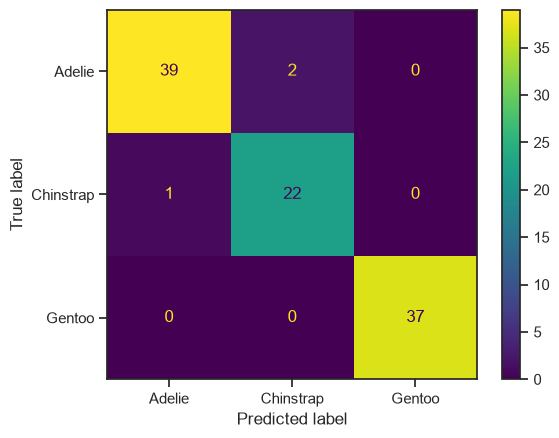

In [403]:
CM_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
CM_plot.plot()

In [404]:
# Create a Classification report (like displayed in the report underneath)
print("Accuracy Score:", accuracy_score(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy Score: 0.9702970297029703

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



### Feature Importance

Very useful attribute of the trained model

In [405]:
# Get the feature importances (.feature_importances_)
model.feature_importances_

array([0.31867744, 0.1018487 , 0.17343398, 0.21316964, 0.14512091,
       0.03720114, 0.00632264, 0.00422556])

In [406]:
# same numbers, with their feature names, sorted from most to least important
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

culmen_length_mm     0.318677
body_mass_g          0.213170
flipper_length_mm    0.173434
island_Dream         0.145121
culmen_depth_mm      0.101849
island_Torgersen     0.037201
sex_FEMALE           0.006323
sex_MALE             0.004226
dtype: float64

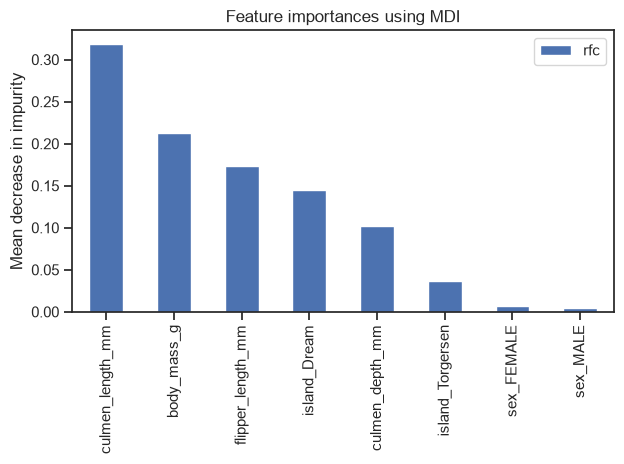

In [407]:
forest_importances = pd.DataFrame({"rfc": model.feature_importances_}, index=X.columns)
forest_importances.sort_values(by = 'rfc', ascending = False, inplace = True)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

### Choosing correct number of trees

Let's explore if continually adding more trees improves performance...

In [408]:
test_error = []

for n in range(1, 40):
    # Use n random trees
    rfc = RandomForestClassifier(n_estimators=n, max_features='sqrt', random_state=101)
    rfc.fit(X_train, y_train)
    test_preds = rfc.predict(X_test)
    test_error.append(1 - accuracy_score(y_test, test_preds))

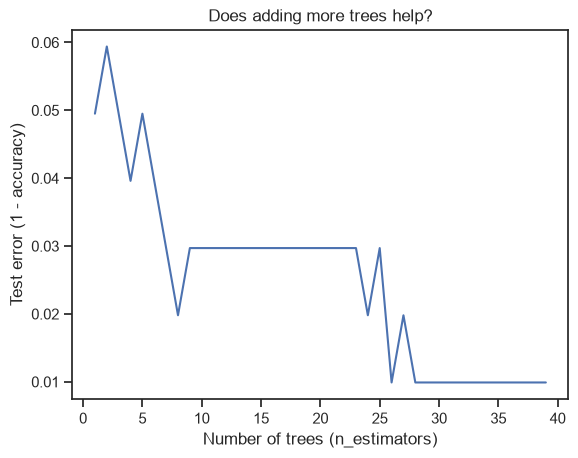

In [409]:
plt.plot(range(1, 40), test_error)
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Test error (1 - accuracy)")
plt.title("Does adding more trees help?")
plt.show()

### Model Performance Analysis

1. **Classification Performance**:
   - With 10 trees the accuracy is 0.97: 98 of the 101 test penguins are right. All 3 mistakes are Adelie/Chinstrap mix-ups (2 Adelies called Chinstrap, 1 the other way). Gentoo is 37 out of 37.

2. **Feature Importance**:
   - culmen_length_mm comes first (0.32), then body_mass_g (0.21) and flipper_length_mm (0.17). The two sex columns are close to 0.
   - The single tree had flipper_length_mm on top (0.54). I'm not sure why the order changes. My guess: with `max_features='sqrt'` each split only looks at 2 of the 8 features, so flipper length often isn't available and the other features get used more.

3. **Number of Trees Analysis**:
   - The error goes from about 5% with 1 tree to 3% around 10 trees, and is 1% (one penguin) from 26 trees on. After that the line stays flat, so 300 trees would only make it slower.

4. **Advantages Over Single Decision Tree**:
   - On penguins the difference is small: the single tree got 0.96, the forest 0.97. The data is easy.
   - A single tree with no depth limit keeps splitting until every leaf is pure, so it learns the training data by heart. Each tree in a forest trains on a different random sample of rows and features, and the trees vote, so one tree's mistakes don't decide the answer. I expect a bigger gap on the Melbourne house prices in Exercise 2.


# Exercises Decision Trees and Random Forests

## Exercise 1. Random Forest Classifier

### 0. Setup

In [410]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import os

### 1. Data Loading

In [411]:
# print(os.getcwd())
# os.chdir('')

# for i in os.listdir():
#     if i.endswith('.csv'):
#         print(i)


In [412]:
# load the data and display first 5 rows
data = pd.read_csv("datasets/loan_data.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


### 2. Data Processing

In [413]:
# get data info and get value_counts for all variables
data.info()
for col in data.select_dtypes(exclude="number").columns.drop("Loan_ID"):
    print(data[col].value_counts(), "\n")

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          381 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 38.8 KB
Gender
Male      291
Female     85
Name: count, dtype: int64 

Married
Yes    228
No     153
Name: count, dtype: int64 

Depend

In [414]:
# count the number of missing values in each column
data.isna().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [415]:
# Use Simple Imputer to fill (fit and transform) missing values in Loan Amount Term
from sklearn.impute import SimpleImputer

# median: almost every loan term is 360 months, so the median is a safe guess
imputer = SimpleImputer(strategy="median")
data[["Loan_Amount_Term"]] = imputer.fit_transform(data[["Loan_Amount_Term"]])
data["Loan_Amount_Term"].isna().sum()

np.int64(0)

In [416]:
# recode 3+ in the variable Dependents to 3
data["Dependents"] = data["Dependents"].replace("3+", "3")
data["Dependents"].value_counts()

Dependents
0    234
2     59
1     52
3     28
Name: count, dtype: int64

In [417]:
# drop rows with NA
data.dropna(inplace = True)

In [418]:
# Use the LabelEncoder to convert categorical 'object' features
from sklearn.preprocessing import LabelEncoder

# Loan_ID is a unique number per application, it says nothing about approval
data = data.drop(columns="Loan_ID")

le = LabelEncoder()
for col in data.select_dtypes(exclude="number").columns:
    data[col] = le.fit_transform(data[col])

In [419]:
# get info and describe the data again
data.info()
data.describe()

<class 'pandas.DataFrame'>
Index: 317 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             317 non-null    int64  
 1   Married            317 non-null    int64  
 2   Dependents         317 non-null    int64  
 3   Education          317 non-null    int64  
 4   Self_Employed      317 non-null    int64  
 5   ApplicantIncome    317 non-null    int64  
 6   CoapplicantIncome  317 non-null    float64
 7   LoanAmount         317 non-null    float64
 8   Loan_Amount_Term   317 non-null    float64
 9   Credit_History     317 non-null    float64
 10  Property_Area      317 non-null    int64  
 11  Loan_Status        317 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 32.2 KB


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.00000
mean,0.791798,0.596215,0.671924,0.264984,0.091483,3606.968454,1267.248959,104.596215,341.716088,0.842271,1.053628,0.70347
std,0.406664,0.491431,0.996640,0.442023,0.288750,1468.731888,2491.928951,29.067050,67.339929,0.365063,0.779663,0.45745
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,36.000000,0.000000,0.000000,0.00000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2583.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.00000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3333.000000,830.000000,110.000000,360.000000,1.000000,1.000000,1.00000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,4301.000000,1950.000000,128.000000,360.000000,1.000000,2.000000,1.00000
max,1.000000,1.000000,3.000000,1.000000,1.000000,9703.000000,33837.000000,150.000000,480.000000,1.000000,2.000000,1.00000


#### Train | Test Split

In [420]:
# Create a training and test set (try to predict loan status)
from sklearn.model_selection import train_test_split

X = data.drop(columns="Loan_Status")
y = data["Loan_Status"]   # after encoding: 0 = N (rejected), 1 = Y (approved)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

#### Feature Scaling

In [421]:
# Use the Standard Scaler to scale (fit and transform) the features for the training and test set
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit only on the training set
X_test = scaler.transform(X_test)         # reuse the training mean/std on the test set

### 3. Model Building

In [422]:
# fit a random forest classifier (criterion = 'entropy' and set a random_state)
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(criterion="entropy", random_state=101)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",101
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap boo

### 4. Evaluation

In [423]:
preds = model.predict(X_test)

In [424]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.56      0.71        36
           1       0.79      1.00      0.88        60

    accuracy                           0.83        96
   macro avg       0.89      0.78      0.80        96
weighted avg       0.87      0.83      0.82        96



In [425]:
# print feature importances with their respective feature names
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

Credit_History       0.251690
ApplicantIncome      0.189609
LoanAmount           0.182216
CoapplicantIncome    0.132192
Property_Area        0.073503
Dependents           0.045221
Loan_Amount_Term     0.041161
Married              0.026136
Education            0.022888
Gender               0.022390
Self_Employed        0.012994
dtype: float64

<Axes: >

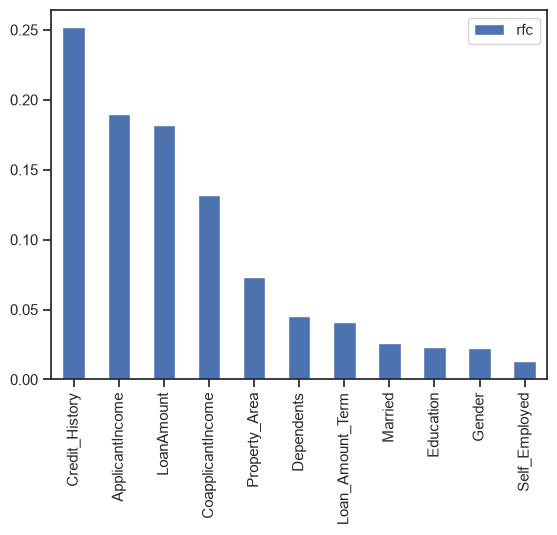

In [426]:
# plot feature importances
forest_importances = pd.DataFrame({"rfc": model.feature_importances_}, index=X.columns)
forest_importances.sort_values(by = 'rfc', ascending = False, inplace = True)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)

#### Conclusion

The forest gets 0.83 accuracy on the 96 test applications. Always answering "approved" would already give 0.63 (60 of 96), so the model does learn something.

The weak spot is the rejected loans (class 0). Recall there is only 0.56: of the 36 loans that were really rejected, the model let 16 through as approved. It never makes the opposite mistake; every loan it rejects really was rejected (precision 1.00). For a bank that's the expensive direction. An approved bad loan costs money, a rejected good one costs a customer.

Credit_History is the most important feature (0.25), followed by ApplicantIncome (0.19) and LoanAmount (0.18).

I dropped Loan_ID before encoding because it's just a unique number per application. Scaling changed nothing: trees split on thresholds, and I got exactly the same results with and without StandardScaler.


## Exercise 2. Random Forest Regressor

This housing dataset provides a thorough analysis of the current state of the housing market. It includes information on housing prices, availability, and key trends, allowing you to gain a better understanding of the market and make informed decisions. 

It is your goal to create a prediction model and actually predict the housing prices of the first five houses in the test set.

### 0. Setup

In [427]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [428]:
# os.chdir("") is not needed: the notebook already runs in this folder
for i in os.listdir("datasets"):
    print(i)

data_banknote_authentication.csv
loan_data.csv
melb_data.csv
penguins_size.csv


### 1. Data Loading

In [429]:
melbourne_housing = pd.read_csv("datasets/melb_data.csv")
melbourne_housing.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [430]:
# drop na and get info
melbourne_housing = melbourne_housing.dropna()
melbourne_housing.info()

<class 'pandas.DataFrame'>
Index: 6196 entries, 1 to 12212
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         6196 non-null   str    
 1   Address        6196 non-null   str    
 2   Rooms          6196 non-null   int64  
 3   Type           6196 non-null   str    
 4   Price          6196 non-null   float64
 5   Method         6196 non-null   str    
 6   SellerG        6196 non-null   str    
 7   Date           6196 non-null   str    
 8   Distance       6196 non-null   float64
 9   Postcode       6196 non-null   float64
 10  Bedroom2       6196 non-null   float64
 11  Bathroom       6196 non-null   float64
 12  Car            6196 non-null   float64
 13  Landsize       6196 non-null   float64
 14  BuildingArea   6196 non-null   float64
 15  YearBuilt      6196 non-null   float64
 16  CouncilArea    6196 non-null   str    
 17  Lattitude      6196 non-null   float64
 18  Longtitude     6196 non

In [431]:
# 13,580 houses before dropna, 6,196 after
melbourne_housing.shape

(6196, 21)

### 2. Data Processing

In [432]:
# Create a features dataframe including 'Rooms', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude' and a target dataframe 'Price'
features = ['Rooms', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude']   # spelling as in the CSV
X = melbourne_housing[features]
y = melbourne_housing['Price']

#### Train | Test Split

In [433]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)   # default: 75% train, 25% test

In [434]:
# describe the features data set
X.describe()

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
count,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.576340,471.006940,-37.807904,144.990201
std,0.971079,0.711362,897.449881,0.075850,0.099165
min,1.000000,1.000000,0.000000,-38.164920,144.542370
25%,2.000000,1.000000,152.000000,-37.855438,144.926198
50%,3.000000,1.000000,373.000000,-37.802250,144.995800
75%,4.000000,2.000000,628.000000,-37.758200,145.052700
max,8.000000,8.000000,37000.000000,-37.457090,145.526350


In [435]:
X.head()

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
1,2,1.0,156.0,-37.8079,144.9934
2,3,2.0,134.0,-37.8093,144.9944
4,4,1.0,120.0,-37.8072,144.9941
6,3,2.0,245.0,-37.8024,144.9993
7,2,1.0,256.0,-37.8060,144.9954


### 3. Model Building

In [436]:
from sklearn.tree import DecisionTreeRegressor

In [437]:
# create and fit the model with random state 1)
model = DecisionTreeRegressor(random_state=1)

In [438]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with 

In [439]:
preds = model.predict(X_test)

### 4. Evaluation

In [440]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [441]:
# calculate the mean absolute error
mean_absolute_error(y_test, preds)

251688.7630729503

In [442]:
# calculate the mean squared error
mse = mean_squared_error(y_test, preds)
print("MSE: ", mse)
print("RMSE:", mse ** 0.5)   # root of MSE, back in dollars

MSE:  215869030528.33313
RMSE: 464617.07946257544


In [443]:
# calculate the r2 score
r2_score(y_test, preds)

0.5506365671927076

mean_absolute_error: Measures the average absolute difference between actual and predicted values. 

mean_squared_error: Measures the average of the squared differences. 

r2_score: Measures how well the predictions approximate the actual values..

### 5. Make predictions

Predict the house price for the first five houses in X

In [444]:
print("Making predictions for the following 5 houses:")
print(X.head())
print("Predicted prices:", model.predict(X.head()))
print("Actual prices:   ", y.head().values)
print("In the training set?", [i in X_train.index for i in X.head().index])

Making predictions for the following 5 houses:
   Rooms  Bathroom  Landsize  Lattitude  Longtitude
1      2       1.0     156.0   -37.8079    144.9934
2      3       2.0     134.0   -37.8093    144.9944
4      4       1.0     120.0   -37.8072    144.9941
6      3       2.0     245.0   -37.8024    144.9993
7      2       1.0     256.0   -37.8060    144.9954
Predicted prices: [1035000. 1465000. 1600000. 1876000. 1242000.]
Actual prices:    [1035000. 1465000. 1600000. 1876000. 1636000.]
In the training set? [True, True, True, True, False]


#### Bonus: training error and a random forest

The heading of this exercise says "Random Forest Regressor", so I also tried one on the same split.

In [445]:
from sklearn.ensemble import RandomForestRegressor

print("Tree MAE on training houses:", mean_absolute_error(y_train, model.predict(X_train)))

forest = RandomForestRegressor(random_state=1)
forest.fit(X_train, y_train)
forest_preds = forest.predict(X_test)
print("Forest MAE on test houses:  ", mean_absolute_error(y_test, forest_preds))
print("Forest R2 on test houses:   ", r2_score(y_test, forest_preds))

Tree MAE on training houses: 863.5678932644716
Forest MAE on test houses:   190383.6844921967
Forest R2 on test houses:    0.7177589834514542


#### Conclusion

My first five predictions look perfect: 1,035,000, 1,465,000, 1,600,000 and 1,876,000 are exactly the real prices. Only the fifth house is off, 1,242,000 against a real 1,636,000.

The last line of that output explains it. The first four houses are in the training set, and a tree with no depth limit remembers every house it trained on. The fifth house is a test house, and there the tree misses by almost $400,000.

The test metrics tell the same story. On houses the tree never saw, the average miss (MAE) is about $252,000. On the training houses it's $864. R² is 0.55, so the tree explains a bit more than half of the differences in price. The MSE (about 2.2 × 10¹¹) is in dollars squared, which I can't read, so I took the root: about $465,000. That's higher than the MAE because some houses get very large errors, and MSE punishes those hardest.

A RandomForestRegressor on the same split brings the MAE down to about $190,000 and R² up to 0.72. That's better, but $190,000 is still a lot for a median house price of $880,000. With only five features I don't think any model gets much closer. I'd like to try adding the house type and the distance to the city centre.
